# Week 3: All Layers Analysis

## Goal

Test **every single layer (1-32)** to find the true optimal layer for our SEP probe.

No more guessing with 8, 10, 16. Let's see the full picture.

---

In [1]:
# Cell 1: Install
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import warnings
import pickle
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
print("Imports ready")

Imports ready


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
    output_hidden_states=True
)
model.eval()

NUM_LAYERS = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size

print(f"Model loaded")
print(f"Total layers: {NUM_LAYERS}")
print(f"Hidden size: {HIDDEN_SIZE}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded
Total layers: 32
Hidden size: 4096


## Training Data

In [4]:
# Cell 4: Training Data (same as before)

TRAIN_EXAMPLES = [
    # CODE UNCERTAINTY (label = 1)
    {'prompt': 'import', 'label': 1},
    {'prompt': 'from sklearn import', 'label': 1},
    {'prompt': 'from tensorflow import', 'label': 1},
    {'prompt': 'def process_data(df):\n    df.', 'label': 1},
    {'prompt': 'result = np.', 'label': 1},
    {'prompt': 'model.', 'label': 1},
    {'prompt': 'const [state, setState] = use', 'label': 1},
    {'prompt': 'import { useState } from', 'label': 1},
    {'prompt': 'async function fetch_data() {\n    await', 'label': 1},
    {'prompt': 'model = tf.keras.', 'label': 1},
    {'prompt': 'optimizer = torch.optim.', 'label': 1},
    {'prompt': 'loss = nn.', 'label': 1},
    {'prompt': 'app = FastAPI()\n@app.', 'label': 1},
    {'prompt': '@app.route', 'label': 1},
    {'prompt': 'router.', 'label': 1},
    {'prompt': 'SELECT * FROM users WHERE', 'label': 1},
    {'prompt': 'db.session.', 'label': 1},
    {'prompt': 'git ', 'label': 1},
    {'prompt': 'docker run -', 'label': 1},
    {'prompt': 'npm ', 'label': 1},

    # LANGUAGE UNCERTAINTY (label = 0)
    {'prompt': 'This function', 'label': 0},
    {'prompt': 'The algorithm is', 'label': 0},
    {'prompt': 'This code works by', 'label': 0},
    {'prompt': 'The main purpose of', 'label': 0},
    {'prompt': 'Code quality can be', 'label': 0},
    {'prompt': 'The architecture is', 'label': 0},
    {'prompt': 'Performance is', 'label': 0},
    {'prompt': 'Explain what this code', 'label': 0},
    {'prompt': 'First, you need to', 'label': 0},
    {'prompt': 'To implement this,', 'label': 0},
    {'prompt': 'The main advantage of async programming is', 'label': 0},
    {'prompt': 'TypeScript provides better', 'label': 0},
    {'prompt': 'The difference between let and const is', 'label': 0},
    {'prompt': 'Recursion is useful when', 'label': 0},
    {'prompt': 'REST APIs are designed to', 'label': 0},
    {'prompt': 'Unit tests help', 'label': 0},
    {'prompt': 'Returns:', 'label': 0},
    {'prompt': 'Args:', 'label': 0},
    {'prompt': 'Note:', 'label': 0},
    {'prompt': 'Warning:', 'label': 0},
]

print(f"Training: {len(TRAIN_EXAMPLES)} examples")
print(f"  Code: {sum(1 for e in TRAIN_EXAMPLES if e['label'] == 1)}")
print(f"  Lang: {sum(1 for e in TRAIN_EXAMPLES if e['label'] == 0)}")

Training: 40 examples
  Code: 20
  Lang: 20


In [5]:
# Cell 5: OOD Test Data

OOD_EXAMPLES = [
    # Different languages
    {'prompt': 'fn main() {', 'label': 1, 'cat': 'rust'},
    {'prompt': 'let mut vec = Vec::', 'label': 1, 'cat': 'rust'},
    {'prompt': 'impl Iterator for', 'label': 1, 'cat': 'rust'},
    {'prompt': 'func main() {', 'label': 1, 'cat': 'go'},
    {'prompt': 'package main\nimport', 'label': 1, 'cat': 'go'},
    {'prompt': 'err := http.', 'label': 1, 'cat': 'go'},
    {'prompt': 'defmodule MyApp do', 'label': 1, 'cat': 'elixir'},
    {'prompt': 'def handle_call(', 'label': 1, 'cat': 'elixir'},
    {'prompt': '|> Enum.', 'label': 1, 'cat': 'elixir'},
    {'prompt': 'fun main() =', 'label': 1, 'cat': 'sml'},
    {'prompt': 'let rec fibonacci n =', 'label': 1, 'cat': 'ocaml'},
    {'prompt': 'data Maybe a =', 'label': 1, 'cat': 'haskell'},
    {'prompt': '#include <', 'label': 1, 'cat': 'c'},
    {'prompt': 'int main(int argc,', 'label': 1, 'cat': 'c'},
    {'prompt': 'std::vector<', 'label': 1, 'cat': 'cpp'},
    {'prompt': 'template<typename T>', 'label': 1, 'cat': 'cpp'},
    {'prompt': 'public class Main {', 'label': 1, 'cat': 'java'},
    {'prompt': 'public static void main(String[]', 'label': 1, 'cat': 'java'},
    {'prompt': '@Override\npublic void', 'label': 1, 'cat': 'java'},
    {'prompt': 'interface User {', 'label': 1, 'cat': 'typescript'},
    {'prompt': 'type Props = {', 'label': 1, 'cat': 'typescript'},
    {'prompt': 'const fn: () =>', 'label': 1, 'cat': 'typescript'},
    {'prompt': 'class User < ApplicationRecord', 'label': 1, 'cat': 'ruby'},
    {'prompt': 'def initialize(', 'label': 1, 'cat': 'ruby'},
    {'prompt': '#!/bin/bash\n', 'label': 1, 'cat': 'shell'},
    {'prompt': 'if [ -f', 'label': 1, 'cat': 'shell'},

    # Niche libraries
    {'prompt': 'import Bio.', 'label': 1, 'cat': 'niche'},
    {'prompt': 'from scanpy import', 'label': 1, 'cat': 'niche'},
    {'prompt': 'model = xgb.', 'label': 1, 'cat': 'niche'},
    {'prompt': 'client = boto3.', 'label': 1, 'cat': 'niche'},
    {'prompt': 'spark.sql(', 'label': 1, 'cat': 'niche'},

    # DevOps
    {'prompt': 'kubectl get', 'label': 1, 'cat': 'devops'},
    {'prompt': 'terraform apply', 'label': 1, 'cat': 'devops'},
    {'prompt': 'ansible-playbook', 'label': 1, 'cat': 'devops'},
    {'prompt': 'aws s3', 'label': 1, 'cat': 'devops'},

    # Edge cases
    {'prompt': '# This imports the', 'label': 0, 'cat': 'edge'},
    {'prompt': '// TODO: implement', 'label': 0, 'cat': 'edge'},
    {'prompt': '/* This function', 'label': 0, 'cat': 'edge'},
    {'prompt': '"""This function calculates', 'label': 0, 'cat': 'edge'},
    {'prompt': "'''\nArgs:\n    x:", 'label': 0, 'cat': 'edge'},
    {'prompt': '```python\nimport', 'label': 1, 'cat': 'edge'},
    {'prompt': 'Here is an example:\n```', 'label': 1, 'cat': 'edge'},
    {'prompt': 'ImportError: No module named', 'label': 0, 'cat': 'edge'},
    {'prompt': 'TypeError: expected', 'label': 0, 'cat': 'edge'},

    # Language
    {'prompt': 'The architecture of this system', 'label': 0, 'cat': 'lang'},
    {'prompt': 'In conclusion, the results show', 'label': 0, 'cat': 'lang'},
    {'prompt': 'To summarize the key findings', 'label': 0, 'cat': 'lang'},
    {'prompt': 'The primary benefit of using', 'label': 0, 'cat': 'lang'},
    {'prompt': 'This approach is preferred because', 'label': 0, 'cat': 'lang'},
    {'prompt': 'Best practices suggest that', 'label': 0, 'cat': 'lang'},
    {'prompt': 'The main challenge is', 'label': 0, 'cat': 'lang'},
    {'prompt': 'One important consideration is', 'label': 0, 'cat': 'lang'},
]

print(f"OOD Test: {len(OOD_EXAMPLES)} examples")
print(f"  Code: {sum(1 for e in OOD_EXAMPLES if e['label'] == 1)}")
print(f"  Lang: {sum(1 for e in OOD_EXAMPLES if e['label'] == 0)}")

OOD Test: 52 examples
  Code: 37
  Lang: 15


## Extract Hidden States from ALL Layers

In [6]:
# Cell 6: Extract ALL hidden states

def get_all_hidden_states(prompt: str) -> Dict[int, np.ndarray]:
    """Extract hidden states from ALL layers for the last token."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # outputs.hidden_states[0] is embedding layer
    # outputs.hidden_states[1] to [32] are transformer layers 1-32
    hidden_states = {}
    for layer_idx in range(1, NUM_LAYERS + 1):
        h = outputs.hidden_states[layer_idx][:, -1, :].squeeze().cpu().numpy()
        hidden_states[layer_idx] = h.astype(np.float32)

    return hidden_states

# Test
test_h = get_all_hidden_states("import pandas")
print(f"Extracted {len(test_h)} layers")
print(f"Each layer shape: {test_h[1].shape}")

Extracted 32 layers
Each layer shape: (4096,)


In [7]:
# Cell 7: Extract training hidden states

print("Extracting hidden states for ALL layers from training data...")
print("(This will take a few minutes)\n")

# Store hidden states: {layer: [examples]}
train_hidden = {layer: [] for layer in range(1, NUM_LAYERS + 1)}
train_labels = []

for example in tqdm(TRAIN_EXAMPLES, desc="Training"):
    all_h = get_all_hidden_states(example['prompt'])

    for layer in range(1, NUM_LAYERS + 1):
        train_hidden[layer].append(all_h[layer])

    train_labels.append(example['label'])

# Convert to numpy
for layer in range(1, NUM_LAYERS + 1):
    train_hidden[layer] = np.array(train_hidden[layer])

train_labels = np.array(train_labels)

print(f"\nDone! Shape per layer: {train_hidden[1].shape}")

Extracting hidden states for ALL layers from training data...
(This will take a few minutes)



Training:   0%|          | 0/40 [00:00<?, ?it/s]


Done! Shape per layer: (40, 4096)


In [8]:
# Cell 8: Extract OOD hidden states

print("Extracting hidden states for ALL layers from OOD data...")

ood_hidden = {layer: [] for layer in range(1, NUM_LAYERS + 1)}
ood_labels = []
ood_categories = []

for example in tqdm(OOD_EXAMPLES, desc="OOD"):
    all_h = get_all_hidden_states(example['prompt'])

    for layer in range(1, NUM_LAYERS + 1):
        ood_hidden[layer].append(all_h[layer])

    ood_labels.append(example['label'])
    ood_categories.append(example['cat'])

for layer in range(1, NUM_LAYERS + 1):
    ood_hidden[layer] = np.array(ood_hidden[layer])

ood_labels = np.array(ood_labels)

print(f"\nDone! Shape per layer: {ood_hidden[1].shape}")

Extracting hidden states for ALL layers from OOD data...


OOD:   0%|          | 0/52 [00:00<?, ?it/s]


Done! Shape per layer: (52, 4096)


## Train and Evaluate Probe at EVERY Layer

In [9]:
# Cell 9: Train probe at every layer

print("Training probes at ALL 32 layers...")
print("="*60)

results = []

for layer in tqdm(range(1, NUM_LAYERS + 1), desc="Layers"):
    X_train = train_hidden[layer]
    y_train = train_labels

    # Normalize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Train with LOO CV for training accuracy
    probe = LogisticRegression(max_iter=1000, random_state=42)
    loo = LeaveOneOut()
    y_pred_train = cross_val_predict(probe, X_train_scaled, y_train, cv=loo)
    train_acc = accuracy_score(y_train, y_pred_train)

    # Train final probe
    probe.fit(X_train_scaled, y_train)

    # Evaluate on OOD
    X_ood = ood_hidden[layer]
    X_ood_scaled = scaler.transform(X_ood)
    y_pred_ood = probe.predict(X_ood_scaled)
    ood_acc = accuracy_score(ood_labels, y_pred_ood)

    # Get probabilities for analysis
    ood_probs = probe.predict_proba(X_ood_scaled)[:, 1]

    results.append({
        'layer': layer,
        'train_acc': train_acc,
        'ood_acc': ood_acc,
        'ood_correct': int(ood_acc * len(ood_labels)),
        'ood_probs': ood_probs,
        'ood_preds': y_pred_ood,
        'probe': probe,
        'scaler': scaler,
    })

print("\nDone!")

Training probes at ALL 32 layers...


Layers:   0%|          | 0/32 [00:00<?, ?it/s]


Done!


In [10]:
# Cell 10: Display results table

print("\n" + "="*60)
print("ACCURACY BY LAYER")
print("="*60)

print(f"\n{'Layer':<8} {'Train Acc':<12} {'OOD Acc':<12} {'Correct':<10}")
print("-"*45)

for r in results:
    marker = " <--" if r['ood_acc'] == max(x['ood_acc'] for x in results) else ""
    print(f"{r['layer']:<8} {r['train_acc']:.1%}        {r['ood_acc']:.1%}        {r['ood_correct']}/{len(ood_labels)}{marker}")

# Find best
best = max(results, key=lambda x: x['ood_acc'])
print(f"\n{'='*45}")
print(f"BEST LAYER: {best['layer']} with {best['ood_acc']:.1%} OOD accuracy")


ACCURACY BY LAYER

Layer    Train Acc    OOD Acc      Correct   
---------------------------------------------
1        90.0%        55.8%        29/52
2        92.5%        65.4%        34/52
3        92.5%        65.4%        34/52
4        95.0%        73.1%        38/52
5        97.5%        82.7%        43/52
6        100.0%        75.0%        39/52
7        100.0%        76.9%        40/52
8        100.0%        73.1%        38/52
9        100.0%        75.0%        39/52
10       100.0%        82.7%        43/52
11       97.5%        80.8%        42/52
12       97.5%        86.5%        45/52
13       97.5%        86.5%        45/52
14       100.0%        84.6%        44/52
15       100.0%        86.5%        45/52
16       100.0%        90.4%        47/52
17       100.0%        90.4%        47/52
18       100.0%        90.4%        47/52
19       100.0%        90.4%        47/52
20       100.0%        90.4%        47/52
21       100.0%        90.4%        47/52
22       100.0

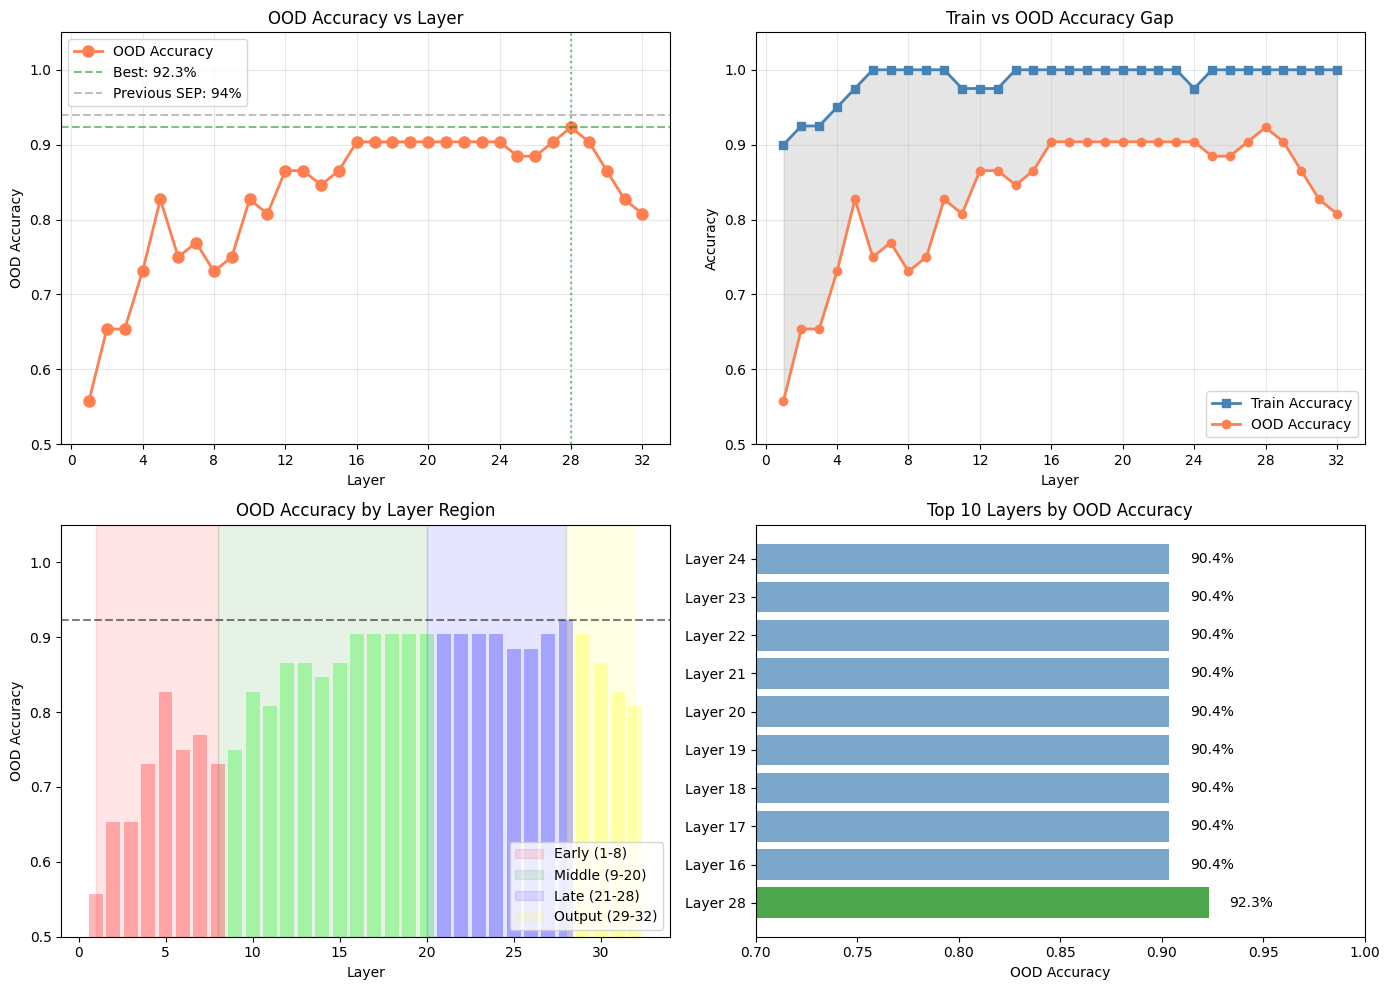

In [11]:
# Cell 11: Visualize the layer curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

layers = [r['layer'] for r in results]
train_accs = [r['train_acc'] for r in results]
ood_accs = [r['ood_acc'] for r in results]

# Plot 1: OOD Accuracy vs Layer
ax1 = axes[0, 0]
ax1.plot(layers, ood_accs, 'o-', color='coral', linewidth=2, markersize=8, label='OOD Accuracy')
ax1.axhline(y=max(ood_accs), color='green', linestyle='--', alpha=0.5, label=f'Best: {max(ood_accs):.1%}')
ax1.axhline(y=0.94, color='gray', linestyle='--', alpha=0.5, label='Previous SEP: 94%')
best_layer = layers[ood_accs.index(max(ood_accs))]
ax1.axvline(x=best_layer, color='green', linestyle=':', alpha=0.5)
ax1.set_xlabel('Layer')
ax1.set_ylabel('OOD Accuracy')
ax1.set_title('OOD Accuracy vs Layer')
ax1.set_ylim(0.5, 1.05)
ax1.set_xticks(range(0, 33, 4))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Train vs OOD Accuracy
ax2 = axes[0, 1]
ax2.plot(layers, train_accs, 's-', color='steelblue', linewidth=2, markersize=6, label='Train Accuracy')
ax2.plot(layers, ood_accs, 'o-', color='coral', linewidth=2, markersize=6, label='OOD Accuracy')
ax2.fill_between(layers, train_accs, ood_accs, alpha=0.2, color='gray')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs OOD Accuracy Gap')
ax2.set_ylim(0.5, 1.05)
ax2.set_xticks(range(0, 33, 4))
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Layer regions
ax3 = axes[1, 0]
colors = ['#ff9999' if l <= 8 else '#99ff99' if 8 < l <= 20 else '#9999ff' if 20 < l <= 28 else '#ffff99' for l in layers]
bars = ax3.bar(layers, ood_accs, color=colors, alpha=0.7)
ax3.axhline(y=max(ood_accs), color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Layer')
ax3.set_ylabel('OOD Accuracy')
ax3.set_title('OOD Accuracy by Layer Region')
ax3.set_ylim(0.5, 1.05)

# Add region labels
ax3.axvspan(1, 8, alpha=0.1, color='red', label='Early (1-8)')
ax3.axvspan(8, 20, alpha=0.1, color='green', label='Middle (9-20)')
ax3.axvspan(20, 28, alpha=0.1, color='blue', label='Late (21-28)')
ax3.axvspan(28, 32, alpha=0.1, color='yellow', label='Output (29-32)')
ax3.legend(loc='lower right')

# Plot 4: Top 10 layers
ax4 = axes[1, 1]
sorted_results = sorted(results, key=lambda x: x['ood_acc'], reverse=True)[:10]
top_layers = [r['layer'] for r in sorted_results]
top_accs = [r['ood_acc'] for r in sorted_results]
colors = ['green' if i == 0 else 'steelblue' for i in range(len(top_layers))]
bars = ax4.barh(range(len(top_layers)), top_accs, color=colors, alpha=0.7)
ax4.set_yticks(range(len(top_layers)))
ax4.set_yticklabels([f'Layer {l}' for l in top_layers])
ax4.set_xlabel('OOD Accuracy')
ax4.set_title('Top 10 Layers by OOD Accuracy')
ax4.set_xlim(0.7, 1.0)
for i, (bar, acc) in enumerate(zip(bars, top_accs)):
    ax4.text(acc + 0.01, i, f'{acc:.1%}', va='center')

plt.tight_layout()
plt.savefig('week3_all_layers_analysis.png', dpi=150)
plt.show()

In [12]:
# Cell 12: Statistical analysis

print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

# Group by region
early = [r for r in results if r['layer'] <= 8]
middle = [r for r in results if 8 < r['layer'] <= 20]
late = [r for r in results if 20 < r['layer'] <= 28]
output = [r for r in results if r['layer'] > 28]

print(f"\nBy Region:")
print(f"  Early (1-8):   avg={np.mean([r['ood_acc'] for r in early]):.1%}, best={max(r['ood_acc'] for r in early):.1%}")
print(f"  Middle (9-20): avg={np.mean([r['ood_acc'] for r in middle]):.1%}, best={max(r['ood_acc'] for r in middle):.1%}")
print(f"  Late (21-28):  avg={np.mean([r['ood_acc'] for r in late]):.1%}, best={max(r['ood_acc'] for r in late):.1%}")
print(f"  Output (29-32):avg={np.mean([r['ood_acc'] for r in output]):.1%}, best={max(r['ood_acc'] for r in output):.1%}")

# Layers we tested before vs optimal
print(f"\nComparison:")
prev_layers = [8, 10, 16]
for l in prev_layers:
    r = results[l-1]
    print(f"  Layer {l}: {r['ood_acc']:.1%}")

print(f"\n  Best (Layer {best['layer']}): {best['ood_acc']:.1%}")

# Did we miss a better layer?
untested = [r for r in results if r['layer'] not in prev_layers and r['ood_acc'] > results[15]['ood_acc']]
if untested:
    print(f"\n  Layers we missed that are better than 16:")
    for r in sorted(untested, key=lambda x: x['ood_acc'], reverse=True):
        print(f"    Layer {r['layer']}: {r['ood_acc']:.1%}")


STATISTICAL ANALYSIS

By Region:
  Early (1-8):   avg=70.9%, best=82.7%
  Middle (9-20): avg=86.2%, best=90.4%
  Late (21-28):  avg=90.1%, best=92.3%
  Output (29-32):avg=85.1%, best=90.4%

Comparison:
  Layer 8: 73.1%
  Layer 10: 82.7%
  Layer 16: 90.4%

  Best (Layer 28): 92.3%

  Layers we missed that are better than 16:
    Layer 28: 92.3%


In [13]:
# Cell 13: Error analysis for best layer

print("\n" + "="*60)
print(f"ERROR ANALYSIS: LAYER {best['layer']}")
print("="*60)

errors = []
for i, (example, pred, prob) in enumerate(zip(OOD_EXAMPLES, best['ood_preds'], best['ood_probs'])):
    if pred != example['label']:
        errors.append({
            'prompt': example['prompt'],
            'category': example['cat'],
            'true': 'CODE' if example['label'] == 1 else 'LANG',
            'pred': 'CODE' if pred == 1 else 'LANG',
            'prob': prob,
        })

print(f"\nTotal errors: {len(errors)}/{len(OOD_EXAMPLES)}")
print("-"*60)

for e in errors:
    print(f"  [{e['category']}] '{e['prompt'][:40]}...'")
    print(f"    True: {e['true']}, Pred: {e['pred']}, P(code)={e['prob']:.2f}")
    print()


ERROR ANALYSIS: LAYER 28

Total errors: 4/52
------------------------------------------------------------
  [rust] 'impl Iterator for...'
    True: CODE, Pred: LANG, P(code)=0.05

  [edge] '# This imports the...'
    True: LANG, Pred: CODE, P(code)=0.96

  [edge] 'ImportError: No module named...'
    True: LANG, Pred: CODE, P(code)=0.95

  [edge] 'TypeError: expected...'
    True: LANG, Pred: CODE, P(code)=0.82



In [14]:
# Cell 14: Compare layers on edge cases specifically

print("\n" + "="*60)
print("EDGE CASE ANALYSIS BY LAYER")
print("="*60)

edge_indices = [i for i, e in enumerate(OOD_EXAMPLES) if e['cat'] == 'edge']
edge_labels = [ood_labels[i] for i in edge_indices]

print(f"\n{'Layer':<8} {'Edge Acc':<12} {'Edge Correct':<15}")
print("-"*35)

edge_results = []
for r in results:
    edge_preds = [r['ood_preds'][i] for i in edge_indices]
    edge_acc = accuracy_score(edge_labels, edge_preds)
    edge_results.append({'layer': r['layer'], 'edge_acc': edge_acc})

    if r['layer'] in [8, 10, 16, best['layer']] or edge_acc == max(x['edge_acc'] for x in edge_results):
        marker = " <-- BEST" if edge_acc == max(x['edge_acc'] for x in edge_results) else ""
        print(f"{r['layer']:<8} {edge_acc:.1%}        {int(edge_acc * len(edge_labels))}/{len(edge_labels)}{marker}")

best_edge = max(edge_results, key=lambda x: x['edge_acc'])
print(f"\nBest layer for edge cases: {best_edge['layer']} ({best_edge['edge_acc']:.1%})")


EDGE CASE ANALYSIS BY LAYER

Layer    Edge Acc     Edge Correct   
-----------------------------------
1        77.8%        7/9 <-- BEST
2        88.9%        8/9 <-- BEST
3        88.9%        8/9 <-- BEST
8        66.7%        6/9
10       66.7%        6/9
16       55.6%        5/9
28       66.7%        6/9

Best layer for edge cases: 2 (88.9%)


In [15]:
# Cell 15: Save best probe

print("\n" + "="*60)
print("SAVING BEST PROBE")
print("="*60)

best_probe_data = {
    'layer': best['layer'],
    'probe': best['probe'],
    'scaler': best['scaler'],
    'train_acc': best['train_acc'],
    'ood_acc': best['ood_acc'],
}

with open('best_layer_probe.pkl', 'wb') as f:
    pickle.dump(best_probe_data, f)

# Save full results
results_df = pd.DataFrame([{
    'layer': r['layer'],
    'train_acc': r['train_acc'],
    'ood_acc': r['ood_acc'],
    'ood_correct': r['ood_correct'],
} for r in results])
results_df.to_csv('week3_all_layers_results.csv', index=False)

print(f"\nSaved:")
print(f"  - best_layer_probe.pkl (Layer {best['layer']})")
print(f"  - week3_all_layers_results.csv")


SAVING BEST PROBE

Saved:
  - best_layer_probe.pkl (Layer 28)
  - week3_all_layers_results.csv


In [16]:
# Cell 16: Final Summary

print("\n" + "="*80)
print("FINAL SUMMARY: ALL LAYERS ANALYSIS")
print("="*80)

print(f"""
QUESTION: Which layer is best for detecting code vs language uncertainty?

ANSWER:
────────────────────────────────────────────────────────────────────────
  Best Overall:     Layer {best['layer']} with {best['ood_acc']:.1%} OOD accuracy
  Best for Edges:   Layer {best_edge['layer']} with {best_edge['edge_acc']:.1%} edge accuracy

PREVIOUS ASSUMPTIONS vs REALITY:
────────────────────────────────────────────────────────────────────────
  Layer 8:  {results[7]['ood_acc']:.1%} (we thought "early = surface features")
  Layer 10: {results[9]['ood_acc']:.1%} (Probing-RAG suggested 1/3 point)
  Layer 16: {results[15]['ood_acc']:.1%} (we thought "middle = semantics")

  Actual best: Layer {best['layer']} ({best['ood_acc']:.1%})

LAYER PROGRESSION PATTERN:
────────────────────────────────────────────────────────────────────────
  Early (1-8):    {np.mean([r['ood_acc'] for r in early]):.1%} average
  Middle (9-20):  {np.mean([r['ood_acc'] for r in middle]):.1%} average
  Late (21-28):   {np.mean([r['ood_acc'] for r in late]):.1%} average
  Output (29-32): {np.mean([r['ood_acc'] for r in output]):.1%} average

CONCLUSION:
────────────────────────────────────────────────────────────────────────
  The empirical best layer is {best['layer']}, not our guessed layers.

  For production, use Layer {best['layer']} probe.
""")

print("="*80)


FINAL SUMMARY: ALL LAYERS ANALYSIS

QUESTION: Which layer is best for detecting code vs language uncertainty?

ANSWER:
────────────────────────────────────────────────────────────────────────
  Best Overall:     Layer 28 with 92.3% OOD accuracy
  Best for Edges:   Layer 2 with 88.9% edge accuracy

PREVIOUS ASSUMPTIONS vs REALITY:
────────────────────────────────────────────────────────────────────────
  Layer 8:  73.1% (we thought "early = surface features")
  Layer 10: 82.7% (Probing-RAG suggested 1/3 point)
  Layer 16: 90.4% (we thought "middle = semantics")
  
  Actual best: Layer 28 (92.3%)

LAYER PROGRESSION PATTERN:
────────────────────────────────────────────────────────────────────────
  Early (1-8):    70.9% average
  Middle (9-20):  86.2% average
  Late (21-28):   90.1% average
  Output (29-32): 85.1% average

CONCLUSION:
────────────────────────────────────────────────────────────────────────
  The empirical best layer is 28, not our guessed layers.
  
  For production, use